<a href="https://colab.research.google.com/github/chamm231305/CS4410-Machine-Learning/blob/main/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data shape: (569, 30)
Target shape: (569,)
X_train shape: (426, 30)
X_test shape: (143, 30)
Model Accuracy (score): 95.10%

Confusion Matrix:
[[44  6]
 [ 1 92]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



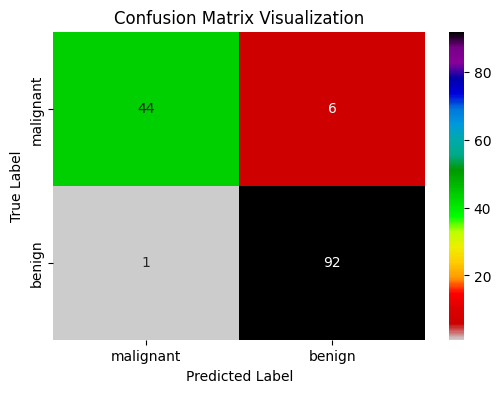

GaussianNB Mean Accuracy: 93.85% (std: 2.75%)

          GaussianNB: mean accuracy = 93.85%; standard deviation = 2.75%
KNeighborsClassifier: mean accuracy = 92.79%; standard deviation = 2.01%
  LogisticRegression: mean accuracy = 95.08%; standard deviation = 3.02%
                 SVC: mean accuracy = 91.92%; standard deviation = 3.52%


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. Loading the Dataset
breast_cancer = load_breast_cancer()

# 2. Checking the Sample and Target Sizes
print(f"Data shape: {breast_cancer.data.shape}")
print(f"Target shape: {breast_cancer.target.shape}")

# 3. Splitting the Data for Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data, breast_cancer.target, random_state=11
)

# 4. Training and Testing Set Sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 5. Creating the Model (GaussianNB)
nb = GaussianNB()

# 6. Training the Model
nb.fit(X=X_train, y=y_train)

# 7. Predicting
predicted = nb.predict(X=X_test)
expected = y_test

# 8. Estimator Method score
print(f"Model Accuracy (score): {nb.score(X_test, y_test):.2%}\n")

# 9. Confusion Matrix
cm = confusion_matrix(y_true=expected, y_pred=predicted)
print("Confusion Matrix:")
print(cm)

# 10. Classification Report
print("\nClassification Report:")
print(classification_report(expected, predicted, target_names=breast_cancer.target_names))

# 11. Visualizing the Confusion Matrix
cm_df = pd.DataFrame(cm, index=breast_cancer.target_names, columns=breast_cancer.target_names)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, cmap='nipy_spectral_r', fmt='d')
plt.title('Confusion Matrix Visualization')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 12. K-Fold Cross-Validation
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

# 13. Using the KFold Object with Function cross_val_score
scores = cross_val_score(estimator=nb, X=breast_cancer.data, y=breast_cancer.target, cv=kfold)
print(f"GaussianNB Mean Accuracy: {scores.mean():.2%} (std: {scores.std():.2%})\n")

# 14. Running Multiple Models to Find the Best One
estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', max_iter=10000),
    'SVC': SVC(gamma='scale')
}

for name, estimator in estimators.items():
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    cv_scores = cross_val_score(estimator=estimator, X=breast_cancer.data, y=breast_cancer.target, cv=kfold)
    print(f"{name:>20}: mean accuracy = {cv_scores.mean():.2%}; standard deviation = {cv_scores.std():.2%}")